In [1]:
import os
import numpy as np 
import pandas as pd
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [2]:
# Load base
df_base = pd.read_csv("../Outputs/ca_patients_filtered.csv")
df_base['hadm_id'] = df_base['hadm_id'].astype(int)

# List of files in desired merge order
merge_files = [
    ("vitals", "../Outputs/vitals_signs_preliminary.csv"),
    ("labs", "../Outputs/lab_vars_preliminary.csv"),
    ("comorbid", "../Outputs/comorbidities_finished.csv"),
    ("marking", "../Outputs/marking_system_finished.csv"),
    ("treatment", "../Outputs/treatment_info_finished.csv")
    #("has_notes", "../Preprocessing/has_radio_disch_notes.csv"),
    #("textual", "../Preprocessing/textual_data_preprocessed.csv"),
]

# Merge step-by-step, dropping duplicate columns (except hadm_id)
df_merged = df_base.copy()
base_columns = set(df_merged.columns)

for name, path in merge_files:
    df = pd.read_csv(path)
    df['hadm_id'] = df['hadm_id'].astype(int)

    # Drop any duplicate columns except 'hadm_id'
    duplicate_cols = base_columns.intersection(set(df.columns)) - {'hadm_id'}
    df = df.drop(columns=list(duplicate_cols))

    # Merge
    df_merged = df_merged.merge(df, on='hadm_id', how='left')
    base_columns.update(df.columns)

print(f"✅ Final merged shape: {df_merged.shape}")

✅ Final merged shape: (2307, 51)


In [3]:
df_merged.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,myocardial_infarction,diabetes_mellitus,copd,GCS_Eye,GCS_Motor,GCS_Verbal,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,0,0,1,2.625,4.0,1.0,7.625,1,0,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,0,0,0,1.000,1.0,1.0,3.000,1,0,0
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,1,0,1,4.000,6.0,5.0,15.000,0,0,0
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,0,0,0,4.000,6.0,5.0,15.000,0,0,1
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,0,0,0,2.500,1.0,1.0,4.500,0,0,0


In [4]:
df_merged.to_csv("../Outputs/final_merged_dataset.csv", index=False)
print("Saved to ../Outputs/final_merged_dataset.csv")

Saved to ../Outputs/final_merged_dataset.csv


In [5]:
# List of columns to drop from df_merged
cols_to_drop = ['icd_code', 'intime', 'outtime', 'los', 'anchor_year', 'anchor_year_group', 'dischtime', 'deathtime', 'dod', 'GCS_Eye', 'GCS_Motor', 'GCS_Verbal']  # Replace with actual column names

# Drop unwanted columns
df = df_merged.drop(columns=cols_to_drop)

print(f"✅ Final shape after dropping columns: {df.shape}")

✅ Final shape after dropping columns: (2307, 39)


In [6]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("📊 Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
HR              0.260078
RR              0.606849
SBP             1.517122
SpO2            1.560468
DBP             1.647161
MBP             1.647161
GCS_Total       2.340702
Sodium          4.204595
Chloride        4.291287
Bicarbonate     4.377980
AnionGap        4.421326
Creatinine      4.421326
Potassium       4.508019
Hematocrit      4.594712
BUN             4.638058
Glucose         4.768097
Hemoglobin      4.854790
Platelet        5.071521
WBC             5.418292
Calcium         6.805375
INR            10.793238
PT             10.923277
BT             13.307326
pH             17.598613
Lactate        19.159081
dtype: float64


In [7]:
"""
# ⚠️ df should already be defined and cleaned as needed

# Step 1: Identify columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"✅ Total columns with missing values: {len(missing_cols)}")

# Optional: drop textual or ID columns if they exist
exclude_cols = ['subject_id', 'hadm_id', 'stay_id', 'gender', 'anchor_age', 'survival_status']  # extend this list as needed
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
impute_targets = [col for col in missing_cols if col in numeric_cols and col not in exclude_cols]

# Step 2: Use other numeric features as predictors
impute_features = [col for col in numeric_cols if col not in exclude_cols]

# Step 3: Target variable (optional, if you're doing modeling too)
target = 'survival_status' if 'survival_status' in df.columns else None

# Step 4: Store Rubin’s rule results
rubin_results = {}

# Step 5: Run multiple imputations
for var in impute_targets:
    print(f"\n▶️ Imputing variable: {var}")
    
    coefs, ses, imputed_versions = [], [], []

    for seed in range(5):
        imputer = IterativeImputer(random_state=seed, max_iter=10, sample_posterior=True)
        imputed_data = imputer.fit_transform(df[impute_features])
        imputed_df = pd.DataFrame(imputed_data, columns=impute_features)

        # Store imputed variable version
        imputed_versions.append(imputed_df[var].copy())

        if target:
            # Prepare data for modeling
            modeling_df = df.copy()
            modeling_df[var] = imputed_df[var]
            modeling_df = modeling_df.dropna(subset=[target] + impute_features)

            # Logistic regression for coefficient
            X = sm.add_constant(modeling_df[impute_features])
            y = modeling_df[target]

            try:
                model = sm.Logit(y, X).fit(disp=0)
                coefs.append(model.params[var])
                ses.append(model.bse[var])
            except Exception as e:
                print(f"⚠️ Regression failed for seed {seed}: {e}")
                continue

    # Rubin’s Rule
    if coefs:
        m = len(coefs)
        beta_mi = np.mean(coefs)
        V = np.mean(np.square(ses))
        B = np.var(coefs, ddof=1)
        T = V + (1 + 1/m) * B
        se_mi = np.sqrt(T)

        rubin_results[var] = {
            'pooled_coef': beta_mi,
            'pooled_se': se_mi,
            '95%_CI': (beta_mi - 1.96 * se_mi, beta_mi + 1.96 * se_mi),
            'imputed_variable': pd.concat(imputed_versions, axis=1).mean(axis=1),
            'coefs': coefs,
            'ses': ses
        }

        print(f"✅ Pooled β ({var}): {beta_mi:.4f}")
        print(f"± SE: {se_mi:.4f}")
        print(f"95% CI: [{beta_mi - 1.96 * se_mi:.4f}, {beta_mi + 1.96 * se_mi:.4f}]")
    else:
        print(f"⚠️ Skipped Rubin’s rule for {var} due to missing regressions.")

# Step 6: Update final df with imputed values
for var in rubin_results:
    df[var] = rubin_results[var]['imputed_variable'].values

print("✅ All imputed variables updated in the dataset.")
"""
print('remove imputation before out of fold cv!')

remove imputation before out of fold cv!


In [8]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("📊 Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
HR              0.260078
RR              0.606849
SBP             1.517122
SpO2            1.560468
DBP             1.647161
MBP             1.647161
GCS_Total       2.340702
Sodium          4.204595
Chloride        4.291287
Bicarbonate     4.377980
AnionGap        4.421326
Creatinine      4.421326
Potassium       4.508019
Hematocrit      4.594712
BUN             4.638058
Glucose         4.768097
Hemoglobin      4.854790
Platelet        5.071521
WBC             5.418292
Calcium         6.805375
INR            10.793238
PT             10.923277
BT             13.307326
pH             17.598613
Lactate        19.159081
dtype: float64


In [9]:
df["gender"] = df["gender"].map({'F': 0, 'M': 1})

In [10]:
df.to_csv("../Outputs/final_structured_dataset.csv", index=False)
df_path = "../Outputs/final_structured_dataset.csv"
df = pd.read_csv(df_path)
df.head()

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,7.340,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,7.190,1,0,0,0,0,3.000,1,0,0
2,10010471,29842315,32119961,0,89,1,86.920000,104.840000,54.280000,68.506667,...,NaN,1,1,1,0,1,15.000,0,0,0
3,10013569,27993048,38857852,0,54,0,80.285714,108.640000,59.080000,72.800000,...,7.350,1,1,0,0,0,15.000,0,0,1
4,10021454,29492087,33300154,1,88,1,57.920000,110.854130,48.005116,68.954787,...,7.362,1,0,0,0,0,4.500,0,0,0


## out of fold cv proabilities using final feature set

In [11]:
final_vars = ['SBP','HR','Lactate','Hemoglobin','Bicarbonate','copd','received_epinephrine',
                    'AnionGap','WBC','RR','BT','PT','congestive_heart_failure','BUN',
                    'anchor_age','pH','SpO2','GCS_Total'] #from Nursultan's pipeline.


In [12]:
final_vars = [
    'SBP', 'HR', 'Lactate', 'Hemoglobin', 'Bicarbonate', 'copd',
    'received_epinephrine', 'AnionGap', 'WBC', 'RR', 'BT', 'PT',
    'congestive_heart_failure', 'BUN', 'anchor_age', 'pH', 'SpO2', 'GCS_Total'
]

binary_vars = ['copd', 'received_epinephrine', 'congestive_heart_failure']
continuous_vars = [col for col in final_vars if col not in binary_vars]

df_model = df[['hadm_id', 'survival_status'] + final_vars].copy()

X_all = df_model[final_vars].copy()
y_all = df_model['survival_status'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_proba = np.full(len(df_model), np.nan)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_tr = X_all.iloc[train_idx].copy()
    X_val = X_all.iloc[val_idx].copy()
    y_tr = y_all.iloc[train_idx].copy()
    y_val = y_all.iloc[val_idx].copy()

    # --- Imputation fit only on training fold ---
    cont_imputer = SimpleImputer(strategy='median')
    bin_imputer = SimpleImputer(strategy='most_frequent')

    X_tr_cont = pd.DataFrame(
        cont_imputer.fit_transform(X_tr[continuous_vars]),
        columns=continuous_vars,
        index=X_tr.index
    )
    X_val_cont = pd.DataFrame(
        cont_imputer.transform(X_val[continuous_vars]),
        columns=continuous_vars,
        index=X_val.index
    )

    X_tr_bin = pd.DataFrame(
        bin_imputer.fit_transform(X_tr[binary_vars]),
        columns=binary_vars,
        index=X_tr.index
    )
    X_val_bin = pd.DataFrame(
        bin_imputer.transform(X_val[binary_vars]),
        columns=binary_vars,
        index=X_val.index
    )

    # Ensure binary columns stay 0/1 integers
    X_tr_bin = X_tr_bin.round().astype(int)
    X_val_bin = X_val_bin.round().astype(int)

    # --- Scaling fit only on training fold ---
    scaler = StandardScaler()

    X_tr_cont_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr_cont),
        columns=continuous_vars,
        index=X_tr.index
    )
    X_val_cont_scaled = pd.DataFrame(
        scaler.transform(X_val_cont),
        columns=continuous_vars,
        index=X_val.index
    )

    # --- Recombine in original column order ---
    X_tr_processed = pd.concat([X_tr_cont_scaled, X_tr_bin], axis=1)[final_vars]
    X_val_processed = pd.concat([X_val_cont_scaled, X_val_bin], axis=1)[final_vars]

    # Add intercept
    X_tr_processed = sm.add_constant(X_tr_processed, has_constant='add')
    X_val_processed = sm.add_constant(X_val_processed, has_constant='add')

    # Fit model
    model = sm.Logit(y_tr, X_tr_processed).fit(disp=0)

    # Predict on held-out fold
    oof_pred_proba[val_idx] = model.predict(X_val_processed)

    fold_auc = roc_auc_score(y_val, oof_pred_proba[val_idx])
    print(f"Fold {fold} AUC: {fold_auc:.4f}")

df_model['baseline_risk_oof'] = oof_pred_proba

print("OOF AUC:", roc_auc_score(y_all, df_model['baseline_risk_oof']))

df_model[['hadm_id', 'survival_status', 'baseline_risk_oof']].to_csv(
    "../Outputs/structured_baseline_risk_oof.csv",
    index=False
)

# ------------------------------
# Optional final model for interpretation
# ------------------------------

# Fit imputers on full dataset only for final descriptive/inferential model
cont_imputer = SimpleImputer(strategy='median')
bin_imputer = SimpleImputer(strategy='most_frequent')
scaler = StandardScaler()

X_cont_full = pd.DataFrame(
    cont_imputer.fit_transform(df_model[continuous_vars]),
    columns=continuous_vars,
    index=df_model.index
)

X_bin_full = pd.DataFrame(
    bin_imputer.fit_transform(df_model[binary_vars]),
    columns=binary_vars,
    index=df_model.index
).round().astype(int)

X_cont_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_cont_full),
    columns=continuous_vars,
    index=df_model.index
)

X_full_processed = pd.concat([X_cont_full_scaled, X_bin_full], axis=1)[final_vars]
X_full_processed = sm.add_constant(X_full_processed, has_constant='add')

final_model = sm.Logit(df_model['survival_status'], X_full_processed).fit()
print(final_model.summary())

Fold 1 AUC: 0.7970
Fold 2 AUC: 0.7780
Fold 3 AUC: 0.7777
Fold 4 AUC: 0.7731
Fold 5 AUC: 0.7733
OOF AUC: 0.7795495970475257
Optimization terminated successfully.
         Current function value: 0.560217
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 2307
Model:                          Logit   Df Residuals:                     2288
Method:                           MLE   Df Model:                           18
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1905
Time:                        22:30:16   Log-Likelihood:                -1292.4
converged:                       True   LL-Null:                       -1596.6
Covariance Type:            nonrobust   LLR p-value:                1.460e-117
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [13]:
df_model_save = df_model.copy()

In [14]:
df_model = df_model_save.copy()

#### OOF AUC: 0.7756051818935 --> randomly pick one patient who died and one who survived, the model assigns a higher death risk to the patient who died about 77.6% of the time.

## tertiles based strata labels

In [15]:
# Compute cutoffs
q1 = df_model['baseline_risk_oof'].quantile(1/3)
q2 = df_model['baseline_risk_oof'].quantile(2/3)

print("Low risk:    <=", q1)
print("Medium risk: >", q1, "and <=", q2)
print("High risk:   >", q2)

# Apply manually
df_model['risk_strata_3'] = pd.cut(
    df_model['baseline_risk_oof'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

print(df_model['risk_strata_3'].value_counts())

Low risk:    <= 0.3792691290789359
Medium risk: > 0.3792691290789359 and <= 0.6311930074883765
High risk:   > 0.6311930074883765
risk_strata_3
low       769
medium    769
high      769
Name: count, dtype: int64


# merge extracted features into dataframes

In [16]:
lactate_path_result = "../LLM Feature Extraction/outputs/lactate_extraction_results_2026-04-02_14-10-58.csv"
shock_path_result = "../LLM Feature Extraction/outputs/shock_extraction_results_2026-04-02_16-36-31.csv"
coma_path_result = "../LLM Feature Extraction/outputs/coma_extraction_results_2026-04-04_12-38-53.csv"

lactate_df = pd.read_csv(lactate_path_result)
shock_df = pd.read_csv(shock_path_result)
coma_df = pd.read_csv(coma_path_result)

In [17]:
df_model = (df_model.merge(lactate_df[['hadm_id', 'llm_present']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_lactate'}))

df_model = (df_model.merge(shock_df[['hadm_id', 'llm_present', 'llm_severity']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_shock', 'llm_severity':'llm_severity_shock'}))

df_model = (df_model.merge(coma_df[['hadm_id', 'llm_present']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_coma'}))

In [18]:
df_model

,hadm_id,survival_status,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,received_epinephrine,AnionGap,...,anchor_age,pH,SpO2,GCS_Total,baseline_risk_oof,risk_strata_3,llm_present_lactate,llm_present_shock,llm_severity_shock,llm_present_coma
0,26184834,1,123.730769,71.392857,1.300000,10.900000,33.000000,1,0,11.000000,...,68,7.340000,98.259259,7.625000,0.361723,low,True,NaN,NaN,NaN
1,29842315,1,104.840000,86.920000,2.150000,11.300000,26.000000,1,0,23.000000,...,89,NaN,97.480000,15.000000,0.387654,medium,True,NaN,NaN,False
2,27993048,0,108.640000,80.285714,NaN,11.350000,30.000000,0,0,19.000000,...,54,7.350000,96.037037,15.000000,0.262898,low,NaN,NaN,NaN,True
3,25154057,1,130.120000,63.111111,4.600000,8.300000,20.000000,1,0,20.333333,...,78,7.350000,99.888889,7.566667,0.724034,high,True,NaN,NaN,True
4,24614671,1,100.848039,72.111111,5.508333,10.983333,16.142857,0,0,20.571429,...,78,7.234286,88.205882,6.666667,0.851821,high,True,True,severe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1613,20917922,0,101.000000,86.812500,1.100000,9.100000,25.750000,0,0,11.250000,...,46,7.360000,96.312500,9.500000,0.314087,low,True,True,severe,True
1614,25848942,0,130.208333,86.680000,1.150000,12.600000,24.000000,1,0,15.000000,...,69,7.250000,96.640000,12.375000,0.428272,medium,False,False,none,False
1615,21588174,1,108.769231,70.261538,0.800000,6.100000,24.500000,1,0,17.500000,...,64,7.400000,98.609375,14.857143,0.514378,medium,NaN,NaN,NaN,False
1616,29695607,0,93.315440,122.041667,3.757143,9.720000,18.800000,0,1,16.000000,...,67,7.279091,90.317073,3.166667,0.782369,high,True,NaN,NaN,True


In [19]:
def summarize_binary_feature(df, feature_col, risk_col='baseline_risk_oof'):
    tmp = df[[feature_col, risk_col]].copy()
    tmp = tmp.dropna(subset=[risk_col])
    
    # Keep null feature values visible as separate category
    tmp[feature_col] = tmp[feature_col].astype('object').where(tmp[feature_col].notna(), 'unknown')
    
    summary = (
        tmp.groupby(feature_col)[risk_col]
        .agg(
            n='count',
            mean='mean',
            median='median',
            std='std',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            min='min',
            max='max'
        )
        .round(4)
    )
    
    display(summary)
    
    # Plot
    groups = []
    labels = []
    for label, g in tmp.groupby(feature_col):
        groups.append(g[risk_col].values)
        labels.append(str(label))
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.ylabel(risk_col)
    plt.title(f'{risk_col} by {feature_col}')
    plt.show()
    
    # Statistical test only for true vs false if both exist
    vals_true = tmp.loc[tmp[feature_col] == True, risk_col]
    vals_false = tmp.loc[tmp[feature_col] == False, risk_col]
    
    if len(vals_true) > 0 and len(vals_false) > 0:
        stat, p = mannwhitneyu(vals_true, vals_false, alternative='two-sided')
        print(f"Mann–Whitney U test for {feature_col}: U={stat:.3f}, p={p:.6f}")
        print(f"Median True:  {vals_true.median():.4f}")
        print(f"Median False: {vals_false.median():.4f}")
    else:
        print(f"Not enough True/False data for Mann–Whitney test in {feature_col}")


def summarize_ordinal_feature(df, feature_col, order, risk_col='baseline_risk_oof'):
    tmp = df[[feature_col, risk_col]].copy()
    tmp = tmp.dropna(subset=[risk_col, feature_col]).copy()
    
    tmp[feature_col] = pd.Categorical(tmp[feature_col], categories=order, ordered=True)
    tmp = tmp.sort_values(feature_col)
    
    summary = (
        tmp.groupby(feature_col, observed=True)[risk_col]
        .agg(
            n='count',
            mean='mean',
            median='median',
            std='std',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
        .round(4)
    )
    
    display(summary)
    
    # Boxplot
    groups = [tmp.loc[tmp[feature_col] == level, risk_col].values for level in order if level in tmp[feature_col].values]
    labels = [level for level in order if level in tmp[feature_col].values]
    
    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.ylabel(risk_col)
    plt.title(f'{risk_col} by {feature_col}')
    plt.show()
    
    # Kruskal-Wallis across severity groups
    valid_groups = [g for g in groups if len(g) > 0]
    if len(valid_groups) >= 2:
        stat, p = kruskal(*valid_groups)
        print(f"Kruskal-Wallis test for {feature_col}: H={stat:.3f}, p={p:.6f}")
    
    # Optional monotonic trend check
    tmp_numeric = tmp.copy()
    tmp_numeric['severity_num'] = tmp_numeric[feature_col].cat.codes
    corr, p_corr = spearmanr(tmp_numeric['severity_num'], tmp_numeric[risk_col])
    print(f"Spearman trend for {feature_col}: rho={corr:.4f}, p={p_corr:.6f}")

,n,mean,median,std,q25,q75,min,max
llm_present_lactate,,,,,,,,
False,230,0.4483,0.4261,0.2121,0.2851,0.5738,0.0823,0.9771
True,790,0.5783,0.5735,0.2379,0.3852,0.7756,0.0763,0.9963
unknown,598,0.4456,0.4146,0.2170,0.2757,0.5984,0.0630,0.9825


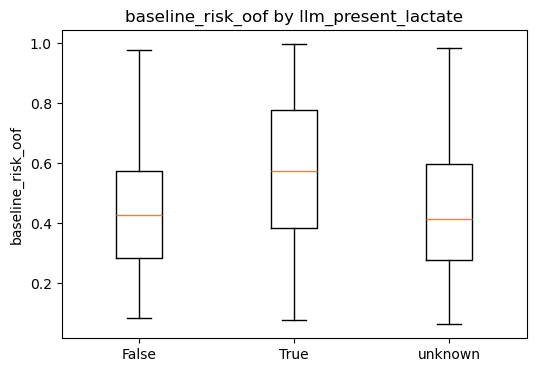

Mann–Whitney U test for llm_present_lactate: U=119522.000, p=0.000000
Median True:  0.5735
Median False: 0.4261


,n,mean,median,std,q25,q75,min,max
llm_present_shock,,,,,,,,
False,306,0.4423,0.4130,0.2299,0.2594,0.6163,0.0679,0.9893
True,505,0.5777,0.5704,0.2373,0.3943,0.7753,0.0763,0.9953
unknown,807,0.4948,0.4638,0.2275,0.3181,0.6646,0.0630,0.9963


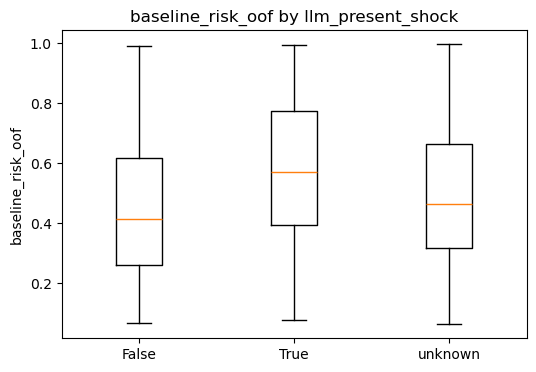

Mann–Whitney U test for llm_present_shock: U=102122.000, p=0.000000
Median True:  0.5704
Median False: 0.4130


,n,mean,median,std,q25,q75,min,max
llm_present_coma,,,,,,,,
False,666,0.4083,0.3705,0.2045,0.2512,0.5451,0.0630,0.9825
True,548,0.5709,0.5675,0.2358,0.3858,0.7594,0.0763,0.9953
unknown,404,0.5981,0.5861,0.2219,0.4226,0.7984,0.1279,0.9963


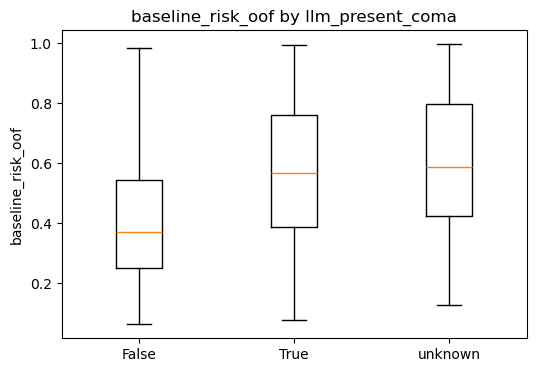

Mann–Whitney U test for llm_present_coma: U=255090.000, p=0.000000
Median True:  0.5675
Median False: 0.3705


,n,mean,median,std,q25,q75
llm_severity_shock,,,,,,
none,306,0.4411,0.4130,0.2290,0.2594,0.6146
mild,2,0.6456,0.6456,0.2431,0.5597,0.7315
moderate,60,0.4869,0.4738,0.1890,0.3546,0.5964
severe,443,0.5905,0.5835,0.2410,0.4105,0.8019


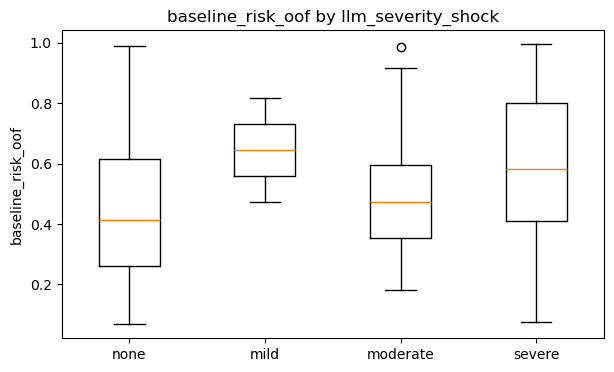

Kruskal-Wallis test for llm_severity_shock: H=70.151, p=0.000000
Spearman trend for llm_severity_shock: rho=0.2921, p=0.000000


In [20]:
summarize_binary_feature(df_model, 'llm_present_lactate')
summarize_binary_feature(df_model, 'llm_present_shock')
summarize_binary_feature(df_model, 'llm_present_coma')

summarize_ordinal_feature(
    df_model,
    'llm_severity_shock',
    order=['none', 'mild', 'moderate', 'severe']
)